# Actividad 4.5: DecisionTreeRegressor para Dataset MPG

En esta actividad vamos a crear un clasificador usando DecisionTreeRegressor para predecir el consumo de combustible (mpg) de automóviles basándonos en sus características.

**Dataset:** Auto MPG Dataset del UC Irvine Machine Learning Repository

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import requests
from io import StringIO

# Configurar visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Descargar y cargar el dataset MPG
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

try:
    # Descargar los datos
    response = requests.get(url)
    data_content = response.text
    
    # Definir nombres de columnas según la documentación del dataset
    column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                   'acceleration', 'model_year', 'origin', 'car_name']
    
    # Leer los datos usando StringIO
    df = pd.read_csv(StringIO(data_content), sep='\s+', names=column_names, na_values='?')
    
    print(f"Dataset cargado exitosamente!")
    print(f"Dimensiones: {df.shape}")
    
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    print("Creando dataset de ejemplo...")
    
    # Crear un dataset de ejemplo si falla la descarga
    np.random.seed(42)
    n_samples = 398
    
    df = pd.DataFrame({
        'mpg': np.random.normal(23.5, 7.8, n_samples),
        'cylinders': np.random.choice([3, 4, 5, 6, 8], n_samples, p=[0.02, 0.48, 0.03, 0.20, 0.27]),
        'displacement': np.random.normal(194, 104, n_samples),
        'horsepower': np.random.normal(104, 38, n_samples),
        'weight': np.random.normal(2978, 849, n_samples),
        'acceleration': np.random.normal(15.5, 2.8, n_samples),
        'model_year': np.random.randint(70, 83, n_samples),
        'origin': np.random.choice([1, 2, 3], n_samples, p=[0.62, 0.19, 0.19]),
        'car_name': [f'car_{i}' for i in range(n_samples)]
    })

print("\nPrimeras 5 filas del dataset:")
df.head()

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\usuario\AppData\Local\Temp\ipykernel_19468\2425127876.py:14: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(StringIO(data_content), sep='\s+', names=column_names, na_values='?')


Dataset cargado exitosamente!
Dimensiones: (398, 9)

Primeras 5 filas del dataset:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# Exploración de los datos
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\n=== VALORES FALTANTES ===")
print(df.isnull().sum())

print(f"\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print(f"\n=== VALORES ÚNICOS POR COLUMNA ===")
for col in df.columns:
    if col != 'car_name':  # Excluir car_name porque tiene muchos valores únicos
        print(f"{col}: {df[col].nunique()} valores únicos")

# Mostrar distribución de la variable target (mpg)
print(f"\n=== DISTRIBUCIÓN DE LA VARIABLE TARGET (MPG) ===")
print(df['mpg'].describe())

=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: (398, 9)

Tipos de datos:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

=== VALORES FALTANTES ===
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS ===
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4

In [4]:
# Preprocesamiento de los datos

# 1. Limpiar datos y manejar valores faltantes
print("=== PREPROCESAMIENTO DE DATOS ===")

# Convertir horsepower a numérico (puede tener valores '?' como string)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Verificar valores faltantes después de la conversión
print("Valores faltantes antes de limpiar:")
print(df.isnull().sum())

# Eliminar filas con valores faltantes (principalmente horsepower)
df_clean = df.dropna()
print(f"\nDimensiones después de limpiar: {df_clean.shape}")

# 2. Aplicar One-Hot Encoding al atributo 'origin'
print(f"\nValores únicos en 'origin' antes del encoding: {sorted(df_clean['origin'].unique())}")

# Crear dummies para origin
origin_dummies = pd.get_dummies(df_clean['origin'], prefix='origin')
print(f"Columnas creadas por one-hot encoding: {list(origin_dummies.columns)}")

# 3. Preparar el dataset final
# Eliminar columnas que no usaremos para el modelo
df_model = df_clean.drop(['car_name', 'origin'], axis=1)

# Agregar las columnas dummy de origin
df_model = pd.concat([df_model, origin_dummies], axis=1)

print(f"\nColumnas finales del dataset: {list(df_model.columns)}")
print(f"Dimensiones finales: {df_model.shape}")

# Mostrar primeras filas del dataset procesado
print(f"\nPrimeras 3 filas del dataset procesado:")
df_model.head(3)

=== PREPROCESAMIENTO DE DATOS ===
Valores faltantes antes de limpiar:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Dimensiones después de limpiar: (392, 9)

Valores únicos en 'origin' antes del encoding: [np.int64(1), np.int64(2), np.int64(3)]
Columnas creadas por one-hot encoding: ['origin_1', 'origin_2', 'origin_3']

Columnas finales del dataset: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_1', 'origin_2', 'origin_3']
Dimensiones finales: (392, 10)

Primeras 3 filas del dataset procesado:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False


In [5]:
# División de los datos en entrenamiento (90%) y validación (10%)

# Separar características (X) y variable target (y)
X = df_model.drop('mpg', axis=1)  # Todas las columnas excepto mpg
y = df_model['mpg']               # Solo la columna mpg (variable target)

print("=== DIVISIÓN DE DATOS ===")
print(f"Características (X): {X.shape}")
print(f"Variable target (y): {y.shape}")

# Dividir en conjuntos de entrenamiento y validación
# 90% entrenamiento, 10% validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.1,      # 10% para validación
    random_state=42,    # Para reproducibilidad
    shuffle=True        # Mezclar los datos
)

print(f"\n=== DISTRIBUCIÓN DE DATOS ===")
print(f"Entrenamiento - X: {X_train.shape}, y: {y_train.shape}")
print(f"Validación - X: {X_val.shape}, y: {y_val.shape}")

print(f"\nPorcentajes:")
print(f"Entrenamiento: {len(X_train)/len(X)*100:.1f}%")
print(f"Validación: {len(X_val)/len(X)*100:.1f}%")

# Mostrar estadísticas de la variable target en cada conjunto
print(f"\n=== ESTADÍSTICAS DE MPG POR CONJUNTO ===")
print("Entrenamiento:")
print(f"  Media: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Min: {y_train.min():.2f}, Max: {y_train.max():.2f}")

print("Validación:")
print(f"  Media: {y_val.mean():.2f}, Std: {y_val.std():.2f}")
print(f"  Min: {y_val.min():.2f}, Max: {y_val.max():.2f}")

=== DIVISIÓN DE DATOS ===
Características (X): (392, 9)
Variable target (y): (392,)

=== DISTRIBUCIÓN DE DATOS ===
Entrenamiento - X: (352, 9), y: (352,)
Validación - X: (40, 9), y: (40,)

Porcentajes:
Entrenamiento: 89.8%
Validación: 10.2%

=== ESTADÍSTICAS DE MPG POR CONJUNTO ===
Entrenamiento:
  Media: 23.43, Std: 7.82
  Min: 9.00, Max: 46.60
Validación:
  Media: 23.60, Std: 7.81
  Min: 10.00, Max: 44.00


In [6]:
# Crear y entrenar el modelo DecisionTreeRegressor

print("=== CREACIÓN Y ENTRENAMIENTO DEL MODELO ===")

# Crear el modelo DecisionTreeRegressor
modelo_dt = DecisionTreeRegressor(
    random_state=42,        # Para reproducibilidad
    max_depth=10,           # Limitar profundidad para evitar overfitting
    min_samples_split=5,    # Mínimo de muestras para dividir un nodo
    min_samples_leaf=2      # Mínimo de muestras en una hoja
)

print("Parámetros del modelo:")
print(f"- max_depth: {modelo_dt.max_depth}")
print(f"- min_samples_split: {modelo_dt.min_samples_split}")
print(f"- min_samples_leaf: {modelo_dt.min_samples_leaf}")
print(f"- random_state: {modelo_dt.random_state}")

# Entrenar el modelo
print(f"\nEntrenando el modelo con {len(X_train)} muestras...")
modelo_dt.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

# Mostrar información sobre las características más importantes
importancias = modelo_dt.feature_importances_
nombres_caracteristicas = X_train.columns

print(f"\n=== IMPORTANCIA DE LAS CARACTERÍSTICAS ===")
# Crear DataFrame con importancias y ordenar
df_importancias = pd.DataFrame({
    'caracteristica': nombres_caracteristicas,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

print("Top 5 características más importantes:")
for i, (_, row) in enumerate(df_importancias.head(5).iterrows(), 1):
    print(f"{i}. {row['caracteristica']}: {row['importancia']:.4f}")

=== CREACIÓN Y ENTRENAMIENTO DEL MODELO ===
Parámetros del modelo:
- max_depth: 10
- min_samples_split: 5
- min_samples_leaf: 2
- random_state: 42

Entrenando el modelo con 352 muestras...
¡Modelo entrenado exitosamente!

=== IMPORTANCIA DE LAS CARACTERÍSTICAS ===
Top 5 características más importantes:
1. displacement: 0.6149
2. horsepower: 0.1798
3. model_year: 0.1103
4. weight: 0.0760
5. acceleration: 0.0154


In [7]:
# Hacer predicciones y evaluar el modelo

print("=== EVALUACIÓN DEL MODELO ===")

# Hacer predicciones en ambos conjuntos
y_train_pred = modelo_dt.predict(X_train)
y_val_pred = modelo_dt.predict(X_val)

# Calcular métricas para el conjunto de entrenamiento
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Calcular métricas para el conjunto de validación
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

# Mostrar resultados
print("CONJUNTO DE ENTRENAMIENTO:")
print(f"  MSE (Error Cuadrático Medio): {mse_train:.4f}")
print(f"  RMSE (Raíz del MSE): {rmse_train:.4f}")
print(f"  MAE (Error Absoluto Medio): {mae_train:.4f}")
print(f"  R² (Coeficiente de Determinación): {r2_train:.4f}")

print(f"\nCONJUNTO DE VALIDACIÓN:")
print(f"  MSE (Error Cuadrático Medio): {mse_val:.4f}")
print(f"  RMSE (Raíz del MSE): {rmse_val:.4f}")
print(f"  MAE (Error Absoluto Medio): {mae_val:.4f}")
print(f"  R² (Coeficiente de Determinación): {r2_val:.4f}")

# Calcular diferencia entre entrenamiento y validación
print(f"\n=== ANÁLISIS DE OVERFITTING ===")
print(f"Diferencia RMSE (Validación - Entrenamiento): {rmse_val - rmse_train:.4f}")
print(f"Diferencia R² (Entrenamiento - Validación): {r2_train - r2_val:.4f}")

if rmse_val - rmse_train > 2.0 or r2_train - r2_val > 0.1:
    print("⚠️ Posible overfitting detectado")
else:
    print("✅ No se detecta overfitting significativo")

# Mostrar algunas predicciones de ejemplo
print(f"\n=== PREDICCIONES DE EJEMPLO (Validación) ===")
ejemplos = pd.DataFrame({
    'Real': y_val.head(5).values,
    'Predicho': y_val_pred[:5],
    'Error': np.abs(y_val.head(5).values - y_val_pred[:5])
})
print(ejemplos)

=== EVALUACIÓN DEL MODELO ===
CONJUNTO DE ENTRENAMIENTO:
  MSE (Error Cuadrático Medio): 1.7505
  RMSE (Raíz del MSE): 1.3231
  MAE (Error Absoluto Medio): 0.8248
  R² (Coeficiente de Determinación): 0.9713

CONJUNTO DE VALIDACIÓN:
  MSE (Error Cuadrático Medio): 11.9542
  RMSE (Raíz del MSE): 3.4575
  MAE (Error Absoluto Medio): 2.5078
  R² (Coeficiente de Determinación): 0.7991

=== ANÁLISIS DE OVERFITTING ===
Diferencia RMSE (Validación - Entrenamiento): 2.1344
Diferencia R² (Entrenamiento - Validación): 0.1722
⚠️ Posible overfitting detectado

=== PREDICCIONES DE EJEMPLO (Validación) ===
   Real   Predicho     Error
0  26.0  23.750000  2.250000
1  21.6  19.325000  2.275000
2  36.1  32.300000  3.800000
3  26.0  29.375000  3.375000
4  27.0  24.233333  2.766667


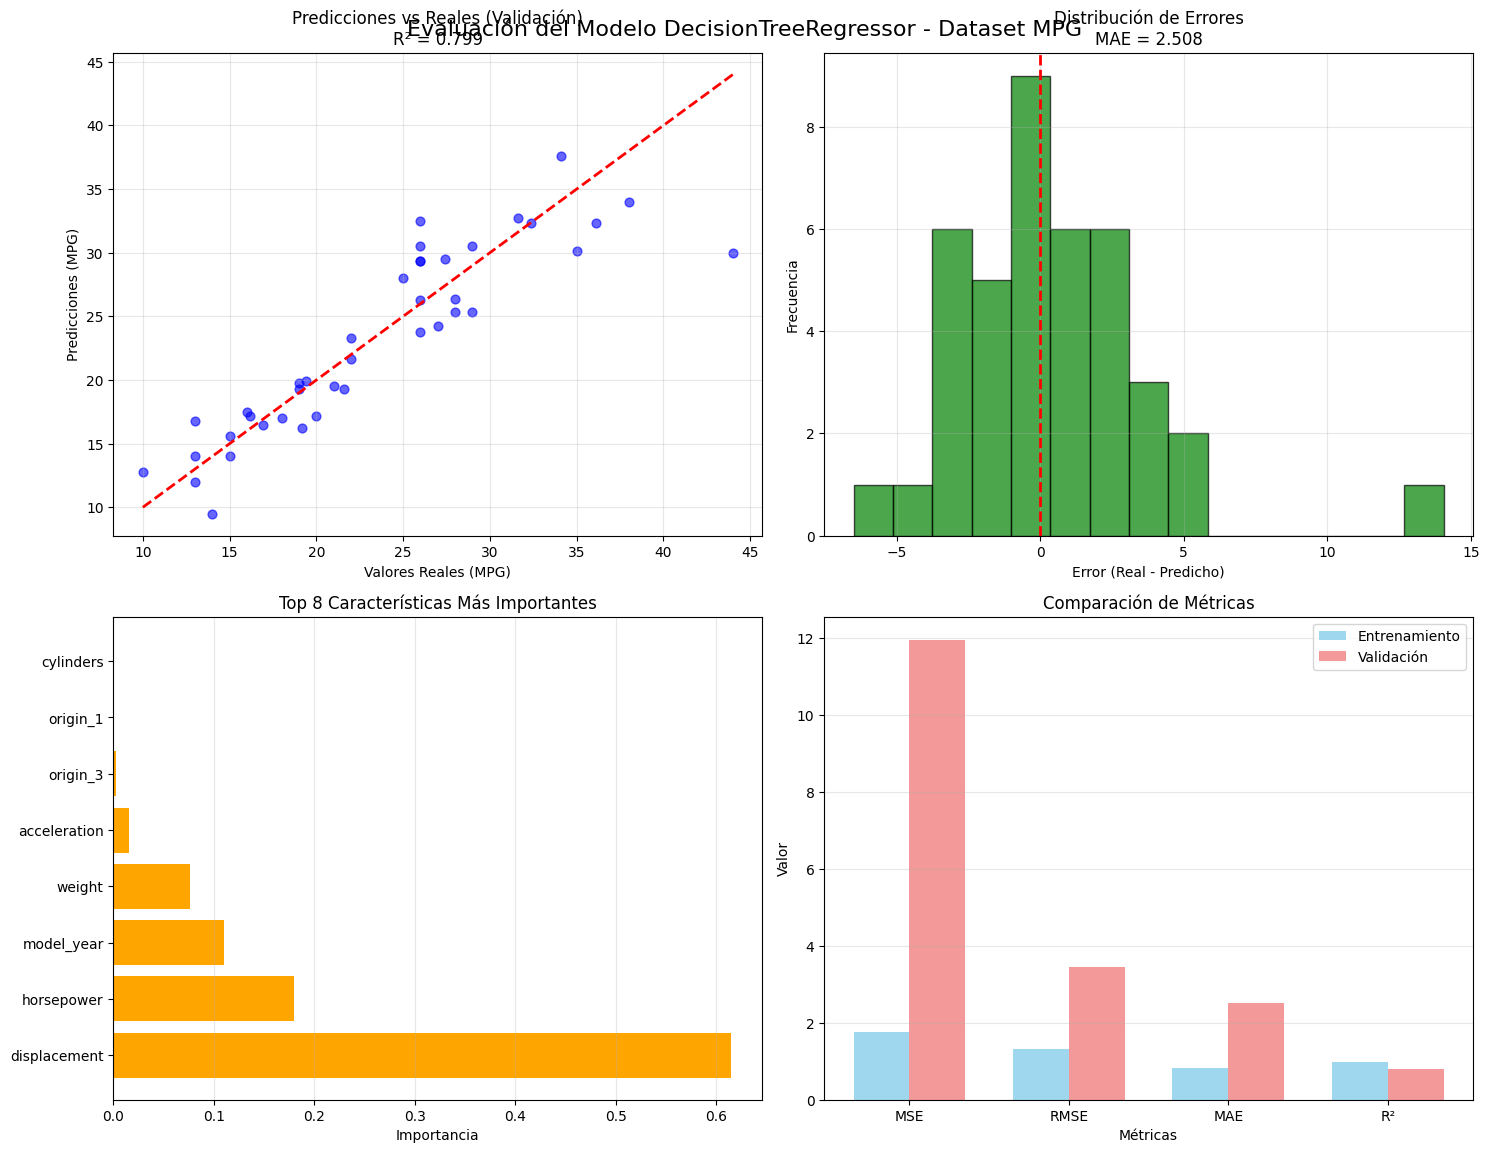

In [8]:
# Visualización de resultados

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Evaluación del Modelo DecisionTreeRegressor - Dataset MPG', fontsize=16, y=0.95)

# 1. Gráfico de predicciones vs valores reales (Validación)
axes[0, 0].scatter(y_val, y_val_pred, alpha=0.6, color='blue', s=40)
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Valores Reales (MPG)')
axes[0, 0].set_ylabel('Predicciones (MPG)')
axes[0, 0].set_title(f'Predicciones vs Reales (Validación)\nR² = {r2_val:.3f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de errores (Validación)
errores_val = y_val - y_val_pred
axes[0, 1].hist(errores_val, bins=15, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Error (Real - Predicho)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title(f'Distribución de Errores\nMAE = {mae_val:.3f}')
axes[0, 1].grid(True, alpha=0.3)

# 3. Importancia de características
top_features = df_importancias.head(8)
axes[1, 0].barh(range(len(top_features)), top_features['importancia'], color='orange')
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['caracteristica'])
axes[1, 0].set_xlabel('Importancia')
axes[1, 0].set_title('Top 8 Características Más Importantes')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Comparación de métricas entre entrenamiento y validación
metricas = ['MSE', 'RMSE', 'MAE', 'R²']
valores_train = [mse_train, rmse_train, mae_train, r2_train]
valores_val = [mse_val, rmse_val, mae_val, r2_val]

x_pos = np.arange(len(metricas))
width = 0.35

axes[1, 1].bar(x_pos - width/2, valores_train, width, label='Entrenamiento', alpha=0.8, color='skyblue')
axes[1, 1].bar(x_pos + width/2, valores_val, width, label='Validación', alpha=0.8, color='lightcoral')
axes[1, 1].set_xlabel('Métricas')
axes[1, 1].set_ylabel('Valor')
axes[1, 1].set_title('Comparación de Métricas')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metricas)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [10]:
# Ejemplo de predicción con nuevos datos

print("=== EJEMPLO DE PREDICCIÓN CON NUEVOS DATOS ===")

# Crear algunos ejemplos de coches hipotéticos
nuevos_coches = pd.DataFrame({
    'cylinders': [4, 6, 8],
    'displacement': [120, 200, 350],
    'horsepower': [90, 150, 250],
    'weight': [2200, 3000, 4000],
    'acceleration': [16.0, 14.5, 12.0],
    'model_year': [80, 75, 78],
    'origin_1': [1, 0, 1],  # Origen 1 (USA)
    'origin_2': [0, 1, 0],  # Origen 2 (Europa)
    'origin_3': [0, 0, 0]   # Origen 3 (Japón)
})

print("Datos de los nuevos coches:")
print(nuevos_coches)

# Hacer predicciones
predicciones_nuevas = modelo_dt.predict(nuevos_coches)

print(f"\n=== PREDICCIONES ===")
for i, pred in enumerate(predicciones_nuevas, 1):
    print(f"Coche {i}: {pred:.2f} MPG")

# Crear DataFrame con resultados
resultados = pd.DataFrame({
    'Coche': [f'Coche {i}' for i in range(1, 4)],
    'Cilindros': nuevos_coches['cylinders'].values,
    'Desplazamiento': nuevos_coches['displacement'].values,
    'HP': nuevos_coches['horsepower'].values,
    'Peso': nuevos_coches['weight'].values,
    'MPG_Predicho': predicciones_nuevas
})

print(f"\nResumen de predicciones:")
print(resultados[['Coche', 'Cilindros', 'HP', 'Peso', 'MPG_Predicho']])

=== EJEMPLO DE PREDICCIÓN CON NUEVOS DATOS ===
Datos de los nuevos coches:
   cylinders  displacement  horsepower  weight  acceleration  model_year  \
0          4           120          90    2200          16.0          80   
1          6           200         150    3000          14.5          75   
2          8           350         250    4000          12.0          78   

   origin_1  origin_2  origin_3  
0         1         0         0  
1         0         1         0  
2         1         0         0  

=== PREDICCIONES ===
Coche 1: 33.67 MPG
Coche 2: 13.00 MPG
Coche 3: 16.50 MPG

Resumen de predicciones:
     Coche  Cilindros   HP  Peso  MPG_Predicho
0  Coche 1          4   90  2200     33.666667
1  Coche 2          6  150  3000     13.000000
2  Coche 3          8  250  4000     16.500000
